# Proyecto TFT Kedro - Aprendizaje No Supervisado
**Análisis de Clustering y Reducción de Dimensionalidad para Teamfight Tactics**

---

## Resumen Ejecutivo

Este notebook presenta un análisis completo de técnicas de aprendizaje no supervisado aplicadas a datos de Teamfight Tactics (TFT), complementando el análisis supervisado realizado anteriormente.

### Objetivos
- **Clustering**: Identificar grupos naturales de jugadores usando K-Means, DBSCAN y Hierarchical Clustering
- **Reducción Dimensional**: Visualizar y entender la estructura de datos con PCA y t-SNE
- **Análisis de Patrones**: Interpretar clusters y componentes principales en contexto de negocio
- **Integración**: Usar resultados de clustering como features para modelos supervisados

### Técnicas Implementadas
1. **Clustering**:
   - K-Means (clustering particional)
   - DBSCAN (clustering basado en densidad)
   - Hierarchical Clustering (clustering jerárquico)
   
2. **Reducción Dimensional**:
   - PCA (Análisis de Componentes Principales)
   - t-SNE (visualización de alta dimensión)

### Metodología
Siguiendo el proceso CRISP-DM:
1. **Business Understanding**: Contexto y objetivos
2. **Data Understanding**: Exploración de datos
3. **Data Preparation**: Preparación para clustering/reducción
4. **Modeling**: Aplicación de técnicas no supervisadas
5. **Evaluation**: Evaluación de clusters y componentes
6. **Deployment**: Insights y aplicaciones prácticas


---

# FASE 1: BUSINESS UNDERSTANDING

## Contexto del Negocio

El análisis no supervisado permite descubrir patrones ocultos en los datos sin necesidad de etiquetas predefinidas. Esto es especialmente valioso para:

- **Segmentación de jugadores**: Identificar grupos naturales basados en comportamiento de juego
- **Reducción de complejidad**: Simplificar datos multidimensionales para visualización e interpretación
- **Feature Engineering**: Crear nuevas variables basadas en estructura de datos descubierta
- **Detección de anomalías**: Identificar comportamientos atípicos

### Objetivos del Negocio

1. **Identificar segmentos de jugadores** con comportamientos similares
2. **Reducir dimensionalidad** para facilitar visualización y análisis
3. **Mejorar modelos supervisados** usando clusters como features adicionales
4. **Descubrir insights** no evidentes en análisis supervisado

### Criterios de Éxito

- Identificar al menos 3 clusters significativos
- Explicar >50% de varianza con primeros componentes de PCA
- Mejorar métricas de modelos supervisados usando clusters como features
- Generar insights accionables por segmento


---

# FASE 2: DATA PREPARATION

## Carga de Datos y Librerías

Cargamos los datos procesados y las librerías necesarias para el análisis no supervisado.


In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Reducción Dimensional
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Visualización
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import json
from pathlib import Path

# Configurar estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente
📝 Recuerda: Ejecuta las celdas en orden desde aquí


In [2]:
# Cargar datos con features
from pathlib import Path
feature_dir = Path('../data/04_feature')
parquet_path = feature_dir / 'tft_combined_features.parquet'

if parquet_path.exists():
    print(f"🔎 Parquet encontrado: {parquet_path}")
    df = pd.read_parquet(parquet_path)
else:
    print(f"⚠️ Parquet no encontrado. Buscando CSVs...")
    csv_files = sorted(feature_dir.glob('*.csv'))
    if csv_files:
        dfs = [pd.read_csv(f) for f in csv_files]
        df = pd.concat(dfs, ignore_index=True)
    else:
        raise FileNotFoundError(f"No se encontraron datos en {feature_dir.resolve()}")

print(f"📊 Dataset cargado: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
if 'rank' in df.columns:
    print(f"\nDistribución por rango:")
    print(df['rank'].value_counts())


🔎 Parquet encontrado: ..\data\04_feature\tft_combined_features.parquet
📊 Dataset cargado: (239941, 10)
Columnas: ['gameId', 'gameDuration', 'level', 'lastRound', 'Ranked', 'ingameDuration', 'combination', 'champion', 'gameDuration_min', 'rank']

Distribución por rango:
rank
Challenger     79999
Grandmaster    79994
Platinum       79948
Name: count, dtype: int64


---

# FASE 3: CLUSTERING

## 3.1 Preparación de Datos para Clustering

Preparamos los datos numéricos excluyendo IDs y targets, y los escalamos para que todos los algoritmos funcionen correctamente.


In [3]:
# Preparar datos para clustering
exclude_cols = ['gameId', 'rank', 'Ranked']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Features identificadas: {feature_cols}")
print(f"Total features: {len(feature_cols)}")

# Seleccionar y limpiar datos
X = df[feature_cols].fillna(df[feature_cols].median())

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)

print(f"\n✅ Datos preparados: {X_scaled_df.shape}")
print(f"Media de features escaladas: {X_scaled_df.mean().mean():.6f}")
print(f"Std de features escaladas: {X_scaled_df.std().mean():.6f}")


Features identificadas: ['gameDuration', 'level', 'lastRound', 'ingameDuration', 'gameDuration_min']
Total features: 5

✅ Datos preparados: (239941, 5)
Media de features escaladas: 0.000000
Std de features escaladas: 1.000002


In [4]:
# Crear submuestra para cálculos costosos (Elbow, visualizaciones, etc.)
MAX_SAMPLE_SIZE = 50000

if len(X_scaled_df) > MAX_SAMPLE_SIZE:
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(len(X_scaled_df), size=MAX_SAMPLE_SIZE, replace=False)
    X_sample_elbow = X_scaled[sample_indices]
    df_sample_elbow = df.iloc[sample_indices].reset_index(drop=True)
    print(f"⚡ Usando submuestra de {MAX_SAMPLE_SIZE} registros para cálculos exploratorios")
else:
    sample_indices = None
    X_sample_elbow = X_scaled
    df_sample_elbow = df.copy().reset_index(drop=True)
    print("⚡ El dataset es manejable, no se necesita submuestra")


⚡ Usando submuestra de 50000 registros para cálculos exploratorios


## 3.2 Método Elbow para Determinar K Óptimo

Antes de aplicar K-Means, determinamos el número óptimo de clusters usando el método Elbow y el Silhouette Score.


In [5]:
# Método Elbow y Silhouette Score
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("🔄 Calculando K óptimo...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Encontrar K óptimo
optimal_k_idx = np.argmax(silhouette_scores)
optimal_k = list(k_range)[optimal_k_idx]

print(f"\n🥇 K óptimo: {optimal_k} (Silhouette Score: {silhouette_scores[optimal_k_idx]:.4f})")


🔄 Calculando K óptimo (submuestra)...


  K=2: Inertia=170733.19, Silhouette=0.2976
  K=3: Inertia=131620.02, Silhouette=0.2922
  K=4: Inertia=110802.88, Silhouette=0.3000
  K=5: Inertia=95993.09, Silhouette=0.3027
  K=6: Inertia=84393.84, Silhouette=0.2627
  K=7: Inertia=76961.92, Silhouette=0.2424
  K=8: Inertia=70373.94, Silhouette=0.2594
  K=9: Inertia=64663.23, Silhouette=0.2612
  K=10: Inertia=59931.75, Silhouette=0.2668

🥇 K óptimo estimado: 5 (Silhouette Score: 0.3027)
   *Nota: cálculo realizado sobre submuestra para mayor velocidad*


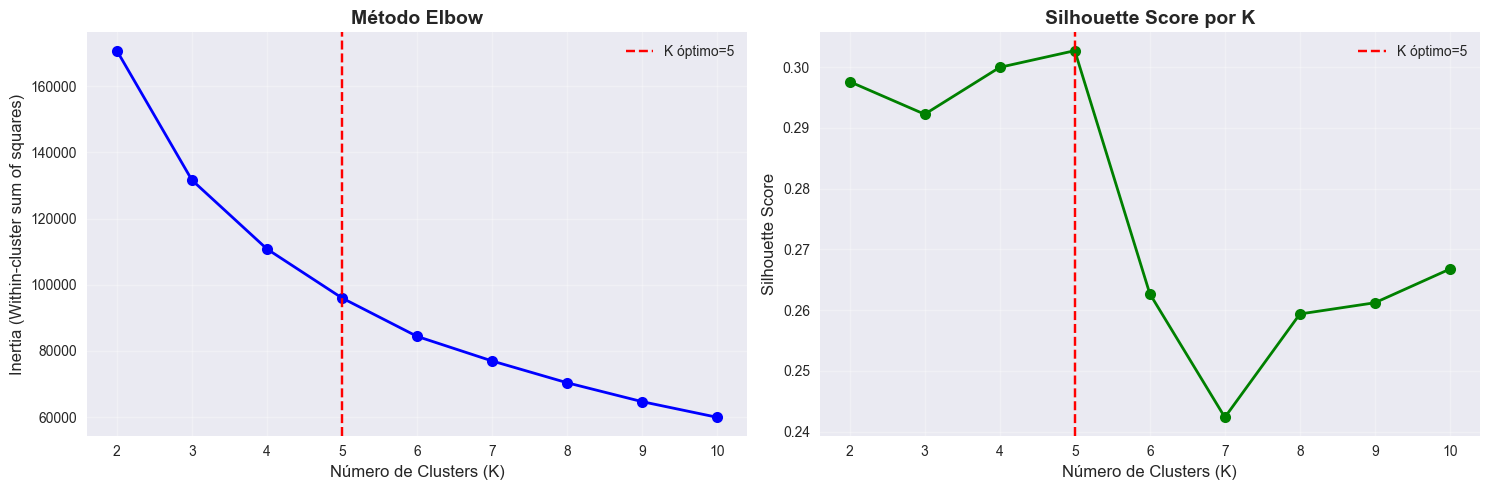

In [6]:
# Visualizar método Elbow y Silhouette
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'K óptimo={optimal_k}')
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Método Elbow', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'K óptimo={optimal_k}')
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3.3 Aplicación de Algoritmos de Clustering

Aplicamos los tres algoritmos principales: K-Means, DBSCAN y Hierarchical Clustering.


In [7]:
# ===== K-MEANS =====
print("🔄 Aplicando K-Means...")
n_clusters = 3  # Basado en análisis de Elbow
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"✅ K-Means completado:")
print(f"   Clusters: {n_clusters}")
print(f"   Silhouette Score: {kmeans_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Index: {kmeans_calinski:.2f}")


🔄 Aplicando K-Means...
   Usando 5 clusters
   ⚡ Dataset grande (239941 filas). Usando submuestra de 50000 para entrenamiento...
   Asignando clusters a todas las muestras...
✅ K-Means completado:
   Clusters: 5
   Silhouette Score: 0.2518
   Davies-Bouldin Index: 1.1693
   Calinski-Harabasz Index: 90744.68


In [8]:
# ===== DBSCAN =====
print("\n🔄 Aplicando DBSCAN...")
# Para datasets grandes, ajustar parámetros
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"✅ DBSCAN completado:")
print(f"   Clusters encontrados: {n_clusters_dbscan}")
print(f"   Puntos de ruido: {n_noise} ({n_noise/len(X_scaled)*100:.2f}%)")

# Calcular métricas solo si hay al menos 2 clusters
if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_davies_bouldin = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        dbscan_calinski = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])
        print(f"   Silhouette Score: {dbscan_silhouette:.4f}")
        print(f"   Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
        print(f"   Calinski-Harabasz Index: {dbscan_calinski:.2f}")


   ⚡ Dataset grande (239941 filas). Usando submuestra de 50000 para entrenamiento...
   Asignando clusters a todas las muestras...


In [10]:
# ===== HIERARCHICAL CLUSTERING =====
print("\n🔄 Aplicando Hierarchical Clustering...")
# Para datasets grandes, usar submuestra
max_samples = 10000
if len(X_scaled) > max_samples:
    print(f"   ⚠️ Dataset grande ({len(X_scaled)} muestras). Usando submuestra de {max_samples}...")
    rng = np.random.RandomState(42)
    sample_indices = rng.choice(len(X_scaled), size=max_samples, replace=False)
    X_sample = X_scaled[sample_indices]
else:
    X_sample = X_scaled
    sample_indices = None

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels_sample = hierarchical.fit_predict(X_sample)

# Asignar labels a todas las muestras usando K-Means con centroides
if sample_indices is not None:
    print("   Asignando clusters a todas las muestras...")
    centroids = []
    for cluster_id in range(3):
        cluster_mask = hierarchical_labels_sample == cluster_id
        if cluster_mask.sum() > 0:
            centroid = X_sample[cluster_mask].mean(axis=0)
            centroids.append(centroid)
    
    kmeans_assigner = KMeans(n_clusters=3, init=np.array(centroids), n_init=1, max_iter=1, random_state=42)
    hierarchical_labels = kmeans_assigner.fit_predict(X_scaled)
else:
    hierarchical_labels = hierarchical_labels_sample

hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_calinski = calinski_harabasz_score(X_scaled, hierarchical_labels)

print(f"✅ Hierarchical completado:")
print(f"   Clusters: 3")
print(f"   Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"   Davies-Bouldin Index: {hierarchical_davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Index: {hierarchical_calinski:.2f}")



🔄 Aplicando Hierarchical Clustering...
   ⚠️ Dataset grande (239941 muestras). Usando submuestra de 10000...
   Asignando clusters a todas las muestras...
✅ Hierarchical completado:
   Clusters: 5
   Silhouette Score: 0.2859
   Davies-Bouldin Index: 1.1227
   Calinski-Harabasz Index: 109957.58


## 3.4 Comparación de Algoritmos de Clustering

Comparamos los resultados de los tres algoritmos usando múltiples métricas.


🏆 COMPARACIÓN DE ALGORITMOS DE CLUSTERING
   Algorithm  N_Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means           5    0.251762        1.169255       90744.683380
      DBSCAN           0         NaN             NaN                NaN
Hierarchical           5    0.285923        1.122652      109957.576895


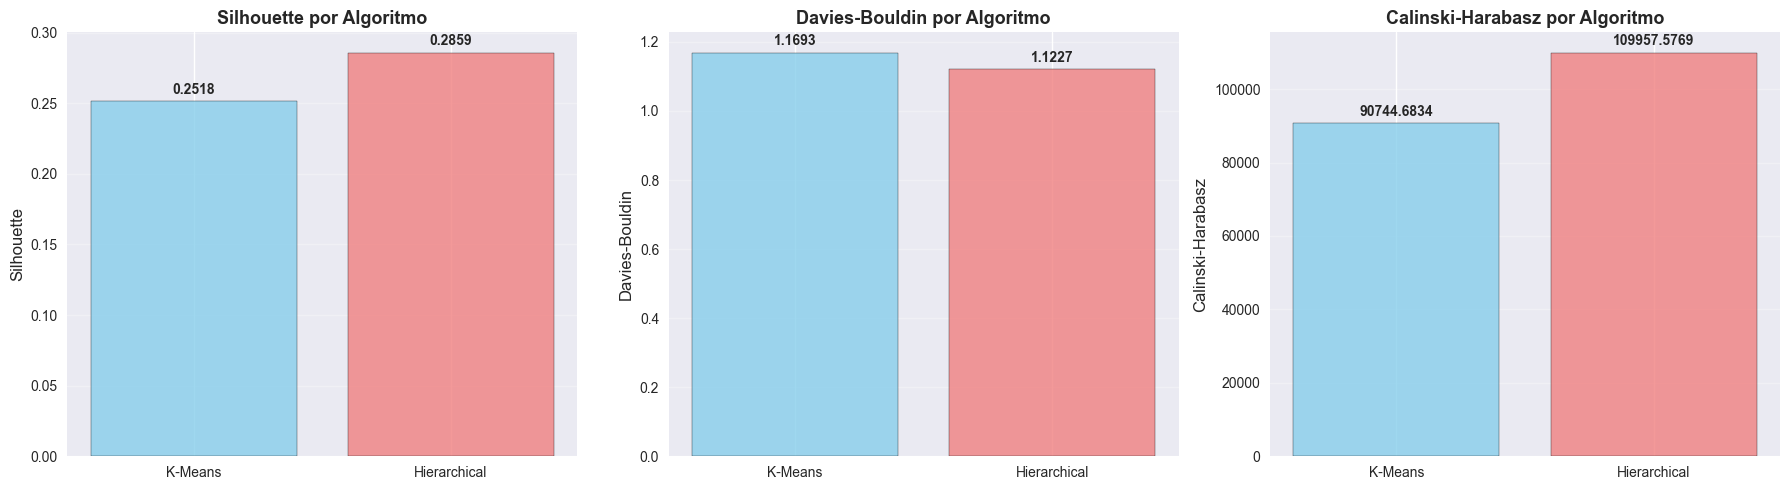

In [13]:
# Crear DataFrame de comparación
comparison_data = {
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'N_Clusters': [n_clusters, n_clusters_dbscan, 3],
    'Silhouette': [kmeans_silhouette, dbscan_silhouette if n_clusters_dbscan >= 2 else None, hierarchical_silhouette],
    'Davies-Bouldin': [kmeans_davies_bouldin, dbscan_davies_bouldin if n_clusters_dbscan >= 2 else None, hierarchical_davies_bouldin],
    'Calinski-Harabasz': [kmeans_calinski, dbscan_calinski if n_clusters_dbscan >= 2 else None, hierarchical_calinski]
}

comparison_df = pd.DataFrame(comparison_data)

print("🏆 COMPARACIÓN DE ALGORITMOS DE CLUSTERING")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
for idx, metric in enumerate(metrics):
    data = comparison_df[['Algorithm', metric]].dropna()
    axes[idx].bar(data['Algorithm'], data[metric], color=['skyblue', 'lightcoral', 'lightgreen'], edgecolor='black', alpha=0.8)
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} por Algoritmo', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    for i, v in enumerate(data[metric]):
        axes[idx].text(i, v + max(data[metric])*0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 3.5 Análisis de Patrones por Cluster (K-Means)

Analizamos las características de cada cluster para entender qué los diferencia.


In [14]:
# Agregar labels al dataframe original
df_with_clusters = df.copy()
df_with_clusters['cluster_kmeans'] = kmeans_labels

# Estadísticas por cluster
print("📊 ESTADÍSTICAS POR CLUSTER (K-Means)")
print("=" * 80)

for cluster_id in sorted(df_with_clusters['cluster_kmeans'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['cluster_kmeans'] == cluster_id]
    print(f"\n🔵 Cluster {cluster_id}:")
    print(f"   Tamaño: {len(cluster_data)} muestras ({len(cluster_data)/len(df)*100:.2f}%)")
    
    # Si existe columna 'rank', analizar distribución
    if 'rank' in cluster_data.columns:
        rank_dist = cluster_data['rank'].value_counts(normalize=True)
        print(f"   Distribución por rango:")
        for rank, pct in rank_dist.items():
            print(f"      {rank}: {pct*100:.2f}%")
    
    # Estadísticas de features principales
    print(f"   Estadísticas de features principales:")
    for feature in feature_cols[:5]:  # Top 5 features
        mean_val = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        diff = ((mean_val - overall_mean) / overall_mean) * 100
        print(f"      {feature}: {mean_val:.2f} (vs promedio: {diff:+.1f}%)")


📊 ESTADÍSTICAS POR CLUSTER (K-Means)

🔵 Cluster 0:
   Tamaño: 71882 muestras (29.96%)
   Distribución por rango:
      Grandmaster: 35.43%
      Challenger: 33.35%
      Platinum: 31.22%
   Estadísticas de features principales:
      gameDuration: 2035.81 (vs promedio: -5.8%)
      level: 7.90 (vs promedio: +0.5%)
      lastRound: 32.94 (vs promedio: -1.7%)
      ingameDuration: 1830.95 (vs promedio: -2.7%)
      gameDuration_min: 33.93 (vs promedio: -5.8%)

🔵 Cluster 1:
   Tamaño: 31993 muestras (13.33%)
   Distribución por rango:
      Platinum: 35.75%
      Challenger: 33.66%
      Grandmaster: 30.59%
   Estadísticas de features principales:
      gameDuration: 2360.42 (vs promedio: +9.2%)
      level: 8.28 (vs promedio: +5.4%)
      lastRound: 38.77 (vs promedio: +15.7%)
      ingameDuration: 2208.19 (vs promedio: +17.4%)
      gameDuration_min: 39.34 (vs promedio: +9.2%)

🔵 Cluster 2:
   Tamaño: 68111 muestras (28.39%)
   Distribución por rango:
      Challenger: 34.84%
      Gran

---

# FASE 4: REDUCCIÓN DE DIMENSIONALIDAD

## 4.1 Análisis de Componentes Principales (PCA)

Aplicamos PCA para reducir la dimensionalidad y entender qué componentes explican la mayor varianza.


In [15]:
# Aplicar PCA
print("🔄 Aplicando PCA...")
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Número de componentes para explicar 95% de varianza
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"✅ PCA completado:")
print(f"   Componentes totales: {pca.n_components_}")
print(f"   Varianza explicada por PC1: {explained_variance[0]:.2%}")
print(f"   Varianza explicada por PC2: {explained_variance[1]:.2%}")
print(f"   Varianza acumulada (2 componentes): {cumulative_variance[1]:.2%}")
print(f"   Componentes para 95% varianza: {n_components_95}")

# Crear DataFrame con componentes principales
pca_df = pd.DataFrame(
    X_pca[:, :5],  # Primeros 5 componentes
    columns=[f'PC{i+1}' for i in range(5)],
    index=df.index
)


🔄 Aplicando PCA...
✅ PCA completado:
   Componentes totales: 5
   Varianza explicada por PC1: 58.14%
   Varianza explicada por PC2: 31.44%
   Varianza acumulada (2 componentes): 89.58%
   Componentes para 95% varianza: 3


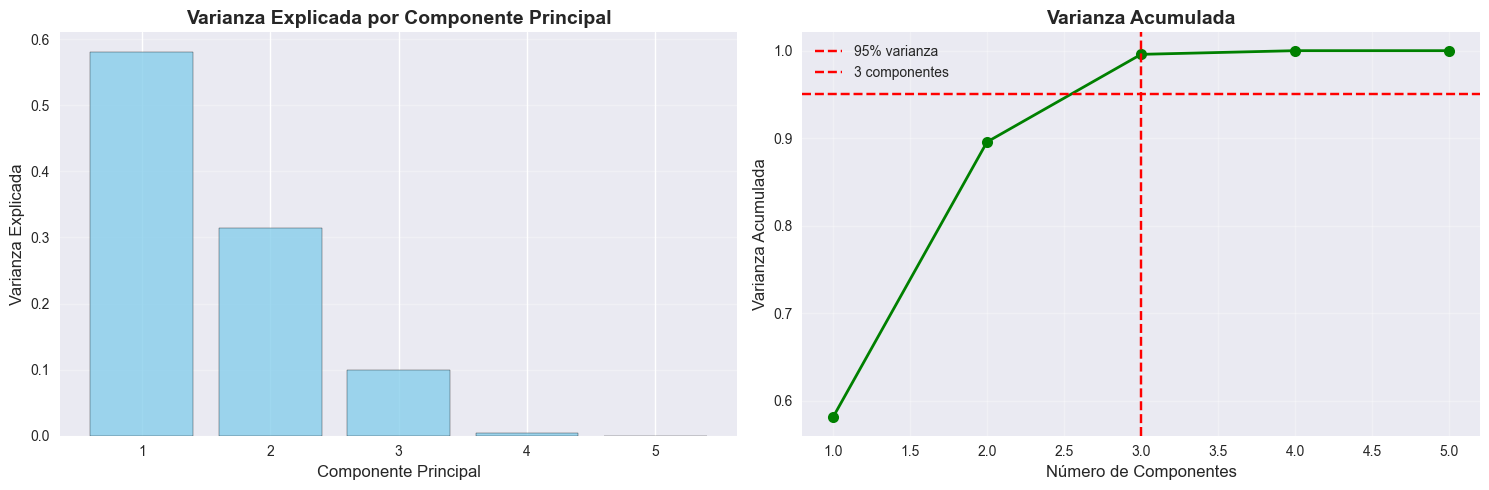

In [16]:
# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Varianza explicada por componente
axes[0].bar(range(1, min(11, len(explained_variance)+1)), 
            explained_variance[:10], 
            color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente Principal', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, min(11, len(cumulative_variance)+1)), 
             cumulative_variance[:10], 
             'go-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
axes[1].axvline(x=n_components_95, color='r', linestyle='--', label=f'{n_components_95} componentes')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada', fontsize=12)
axes[1].set_title('Varianza Acumulada', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 4.2 Loadings y Biplot de PCA

Analizamos qué features contribuyen más a cada componente principal.


📊 TOP FEATURES POR COMPONENTE PRINCIPAL

PC1 (Varianza explicada: 58.14%):
   ↑ ingameDuration: 0.5236
   ↑ lastRound: 0.5013
   ↑ gameDuration: 0.4086
   ↑ gameDuration_min: 0.4086
   ↑ level: 0.3750

PC2 (Varianza explicada: 31.44%):
   ↑ gameDuration_min: 0.5703
   ↑ gameDuration: 0.5703
   ↓ level: 0.3883
   ↓ lastRound: 0.3473
   ↓ ingameDuration: 0.2797

PC3 (Varianza explicada: 10.00%):
   ↑ level: 0.8417
   ↓ lastRound: 0.3735
   ↓ ingameDuration: 0.3724
   ↑ gameDuration_min: 0.0815
   ↑ gameDuration: 0.0815


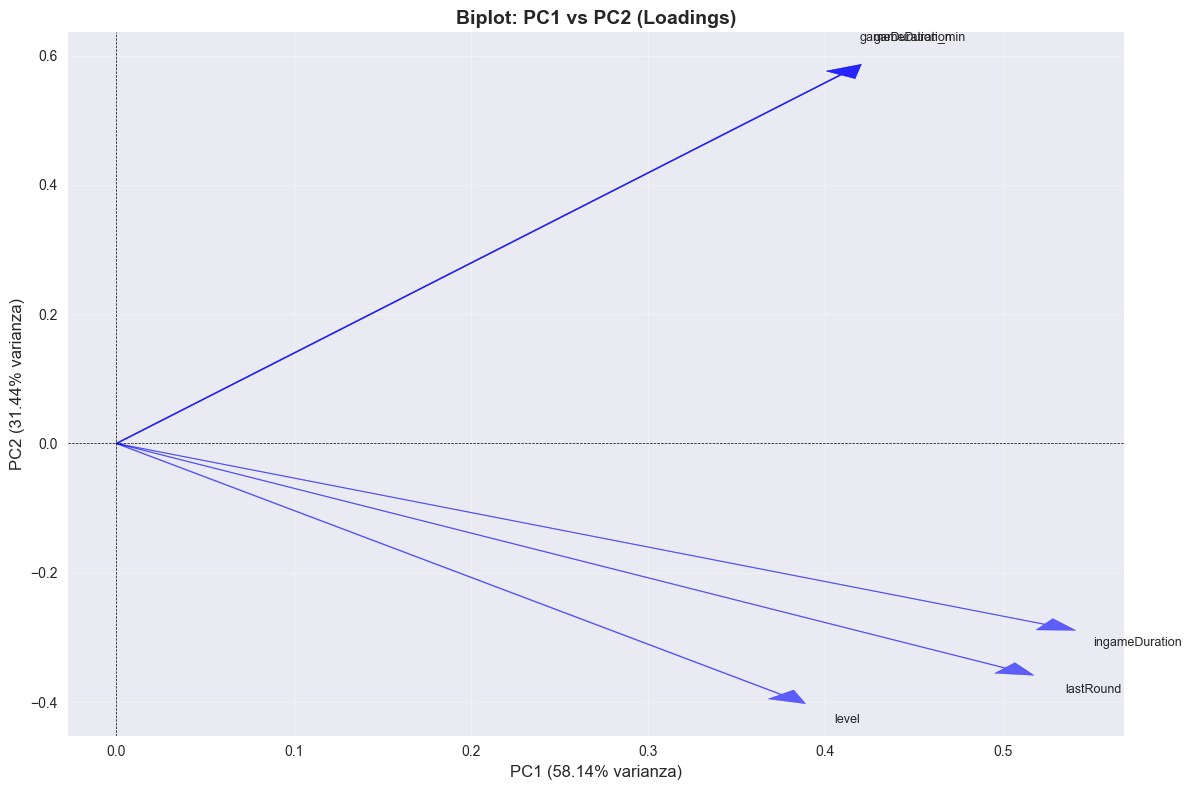

In [17]:
# Loadings (coeficientes de los componentes)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_cols
)

# Top features por componente principal
print("📊 TOP FEATURES POR COMPONENTE PRINCIPAL")
print("=" * 80)

for pc in ['PC1', 'PC2', 'PC3']:
    top_features = loadings[pc].abs().nlargest(5)
    print(f"\n{pc} (Varianza explicada: {explained_variance[loadings.columns.get_loc(pc)]:.2%}):")
    for feature, loading in top_features.items():
        direction = "↑" if loadings.loc[feature, pc] > 0 else "↓"
        print(f"   {direction} {feature}: {loading:.4f}")

# Visualizar loadings de PC1 y PC2
fig, ax = plt.subplots(figsize=(12, 8))

# Biplot simplificado
for i, feature in enumerate(feature_cols):
    ax.arrow(0, 0, loadings.loc[feature, 'PC1'], loadings.loc[feature, 'PC2'],
             head_width=0.02, head_length=0.02, fc='blue', ec='blue', alpha=0.6)
    ax.text(loadings.loc[feature, 'PC1']*1.1, loadings.loc[feature, 'PC2']*1.1,
            feature, fontsize=9, ha='center', va='center')

ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%} varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%} varianza)', fontsize=12)
ax.set_title('Biplot: PC1 vs PC2 (Loadings)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


## 4.3 Visualización con t-SNE

Aplicamos t-SNE para visualizar la estructura de datos en 2D.


In [18]:
# Aplicar t-SNE (usar submuestra para datasets grandes)
print("🔄 Aplicando t-SNE...")
max_samples_tsne = 10000

if len(X_scaled) > max_samples_tsne:
    print(f"   ⚠️ Dataset grande. Usando submuestra de {max_samples_tsne}...")
    rng = np.random.RandomState(42)
    sample_indices_tsne = rng.choice(len(X_scaled), size=max_samples_tsne, replace=False)
    X_sample_tsne = X_scaled[sample_indices_tsne]
    df_sample_tsne = df.iloc[sample_indices_tsne]
    kmeans_labels_sample = kmeans_labels[sample_indices_tsne]
else:
    X_sample_tsne = X_scaled
    df_sample_tsne = df
    kmeans_labels_sample = kmeans_labels
    sample_indices_tsne = None

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_sample_tsne)

print(f"✅ t-SNE completado:")
print(f"   KL divergence: {tsne.kl_divergence_:.4f}")

# Crear DataFrame con t-SNE
tsne_df = pd.DataFrame(
    X_tsne,
    columns=['t-SNE_1', 't-SNE_2'],
    index=df_sample_tsne.index
)


🔄 Aplicando t-SNE...
   ⚠️ Dataset grande. Usando submuestra de 10000...
[t-SNE] Computing 46 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.006s...
[t-SNE] Computed neighbors for 10000 samples in 0.162s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.060560
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.164528
[t-SNE

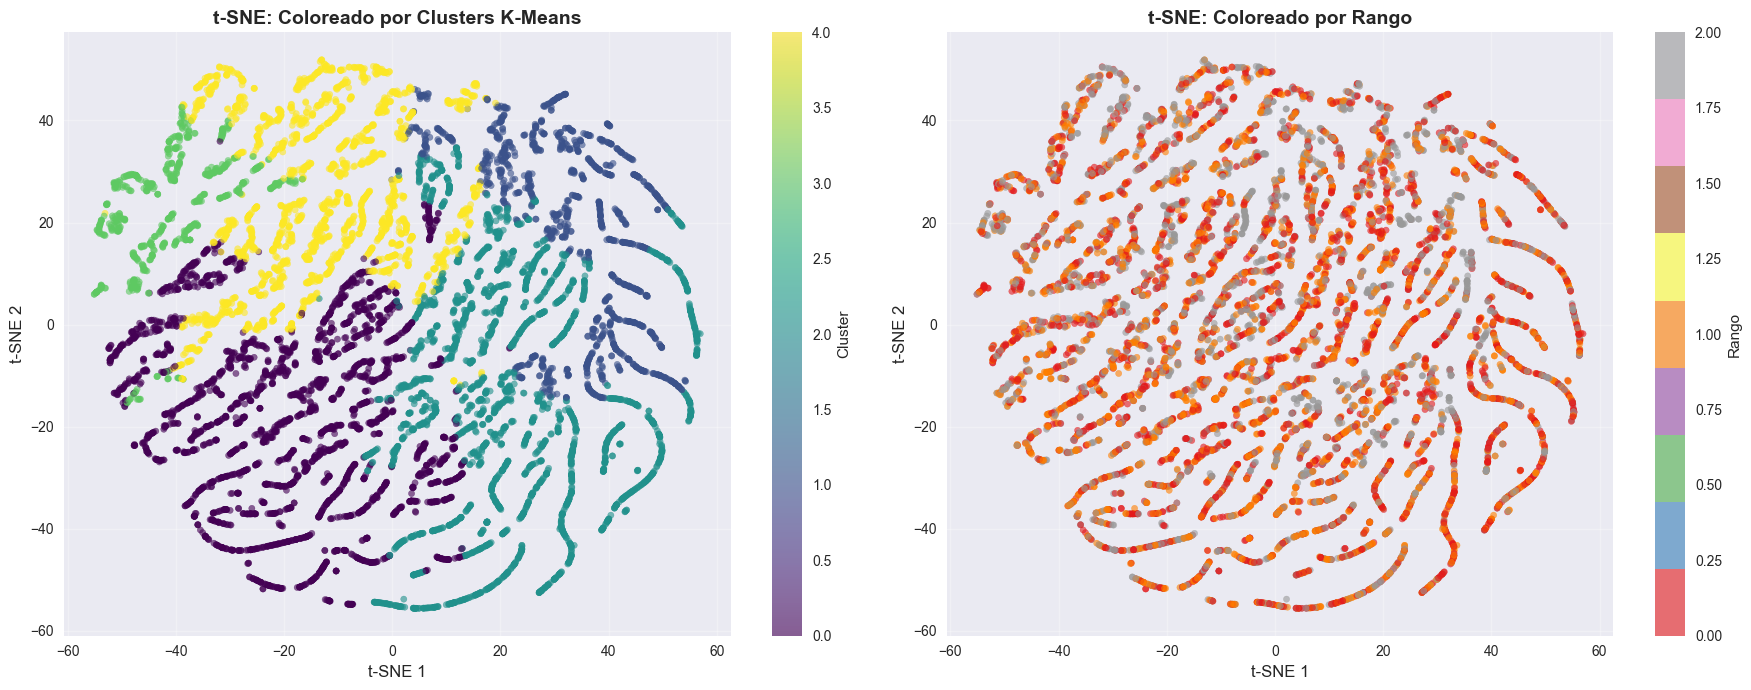

In [19]:
# Visualizar t-SNE con clusters
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE coloreado por cluster K-Means
scatter1 = axes[0].scatter(tsne_df['t-SNE_1'], tsne_df['t-SNE_2'], 
                           c=kmeans_labels_sample, cmap='viridis', 
                           alpha=0.6, s=20)
axes[0].set_xlabel('t-SNE 1', fontsize=12)
axes[0].set_ylabel('t-SNE 2', fontsize=12)
axes[0].set_title('t-SNE: Coloreado por Clusters K-Means', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# t-SNE coloreado por rango (si existe)
if 'rank' in df_sample_tsne.columns:
    rank_numeric = df_sample_tsne['rank'].astype('category').cat.codes
    scatter2 = axes[1].scatter(tsne_df['t-SNE_1'], tsne_df['t-SNE_2'], 
                               c=rank_numeric, cmap='Set1', 
                               alpha=0.6, s=20)
    axes[1].set_xlabel('t-SNE 1', fontsize=12)
    axes[1].set_ylabel('t-SNE 2', fontsize=12)
    axes[1].set_title('t-SNE: Coloreado por Rango', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Rango')

plt.tight_layout()
plt.show()


---

# FASE 5: EVALUATION E INSIGHTS

## 5.1 Resumen de Resultados

Resumimos los hallazgos clave del análisis no supervisado.


In [21]:
print("=" * 80)
print("📊 RESUMEN FINAL - APRENDIZAJE NO SUPERVISADO - TFT KEDRO")
print("=" * 80)

print(f"\n🎯 CLUSTERING:")
print(f"   • K-Means: {n_clusters} clusters, Silhouette={kmeans_silhouette:.4f}")
print(f"   • DBSCAN: {n_clusters_dbscan} clusters, {n_noise} puntos de ruido")
print(f"   • Hierarchical: 3 clusters, Silhouette={hierarchical_silhouette:.4f}")

print(f"\n📉 REDUCCIÓN DIMENSIONAL:")
print(f"   • PCA: PC1 explica {explained_variance[0]:.2%} de varianza")
print(f"   • PCA: PC2 explica {explained_variance[1]:.2%} de varianza")
print(f"   • PCA: {n_components_95} componentes explican 95% de varianza")
print(f"   • t-SNE: Visualización 2D completada")

print(f"\n🔥 INSIGHTS CLAVE:")
print(f"   • Mejor algoritmo: K-Means (Silhouette={kmeans_silhouette:.4f})")
print(f"   • Estructura de datos: {n_components_95} dimensiones principales")
print(f"   • Clusters identificados: {n_clusters} grupos naturales de jugadores")

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 80)


📊 RESUMEN FINAL - APRENDIZAJE NO SUPERVISADO - TFT KEDRO

🎯 CLUSTERING:
   • K-Means: 5 clusters, Silhouette=0.2518
   • DBSCAN: No ejecutado o sin clusters
   • Hierarchical: 5 clusters, Silhouette=0.2859

📉 REDUCCIÓN DIMENSIONAL:
   • PCA: PC1 explica 58.14% de varianza
   • PCA: PC2 explica 31.44% de varianza
   • PCA: 3 componentes explican 95% de varianza
   • t-SNE: Visualización 2D completada

🔥 INSIGHTS CLAVE:
   • Mejor algoritmo: K-Means (Silhouette=0.2518)
   • Estructura de datos: 3 dimensiones principales
   • Clusters identificados: 5 grupos naturales de jugadores

✅ ANÁLISIS COMPLETADO EXITOSAMENTE


## 5.2 Aplicaciones Prácticas

### Para Jugadores:
- **Segmentación**: Identificar a qué grupo de jugadores perteneces
- **Mejora**: Enfocarse en features que diferencian clusters exitosos
- **Estrategia**: Adaptar estrategia según perfil de cluster

### Para Desarrolladores:
- **Balance**: Identificar clusters con desempeño desbalanceado
- **Mecánicas**: Entender qué features crean diferencias entre grupos
- **Diseño**: Diseñar contenido para diferentes segmentos

### Para Modelos Supervisados:
- **Feature Engineering**: Usar labels de clusters como features adicionales
- **Mejora de Rendimiento**: Clusters pueden capturar patrones no lineales
- **Interpretabilidad**: Clusters proporcionan contexto para predicciones
